In [1]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np

import seaborn as sns
sns.set(color_codes=True)
sns.set_style('white')

In [2]:
np.random.uniform(low=0.0, high=1.0)

0.8585407991576819

In [3]:
# generate a flip
def flip(num=1):
    flips = []

    for i in range(num):
        num = np.random.uniform(low=0.0, high=1.0)
        if num > 0.5:
            flips.append('H')              # should be using yield here if you know generators
        else:
            flips.append('T')
    return flips

In [4]:
flip()

['H']

In [5]:
flips = flip(10)
print(flips)

['T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'H', 'H']


In [6]:
values, counts = np.unique(flips, return_counts=True)

In [7]:
values, counts

(array(['H', 'T'], dtype='<U1'), array([5, 5]))

In [8]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np

import seaborn as sns
sns.set(color_codes=True)
sns.set_style('white')

# generate a flip
def flip(num=1):
    flips = []

    for i in range(num):
        num = np.random.uniform(low=0.0, high=1.0)
        if num > 0.5:
            flips.append('H')              # should be using yield here if you know generators
        else:
            flips.append('T')
    return flips

flips = flip(10)
values, counts = np.unique(flips, return_counts=True)

# print(flip())
print(flips)
print(counts)

['H', 'T', 'H', 'H', 'H', 'T', 'T', 'T', 'T', 'H']
[5 5]


# Reproducible 'Randomness'

In [9]:
# there's a problem in the above code that if we are running this on a large scale data, and then if we 
# come across a bug or an error it will be gone when we reproduce the random numbers because that values 
# will be gone for that we will produce the values as that they will predictable, not hard coded. If we make
# them hard coded then the foundation of finding the probability will be dead. 
# this is a very huge problem and these types of bugs are called heisenbugs. 
# heisenbugs are those bugs which come up when we are not looking and when we are trying to find them, in 
# order to fix them, they cannot be found.
# that's why when we debug we want the reproducible (predictable) random numbers 

In [10]:
# understand the difference between hardcoding and this method?
# there is no randomness in hardcoding, there is randomness in this method but the way this randomness 
# created, it is predictable. This predictability comes from changing a single line, we can disable this 
# only by changing that line.

In [11]:
# computers are deterministic machines. You cannot do 'random' in computers.
# so, you start with some 'seed' then do deterministic things.
# this is called pseudo-rnadomness

# sometimes you want to suppress this

np.random.seed(0)          # random numbers and seeds

In [12]:
np.random.uniform(low=0.0, high=1.0)

0.5488135039273248

In [13]:
# so whenever we are doing our data science experiments or machine learning experiments, imidiately after
# importing the numpy array, we have to set the any number (should be fixed) to the "np.random.seed(number)" 

In [14]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np

import seaborn as sns
sns.set(color_codes=True)
sns.set_style('white')

np.random.seed(1337)          # random numbers and seeds

# generate a flip
def flip(num=1):
    flips = []

    for i in range(num):
        num = np.random.uniform(low=0.0, high=1.0)
        if num > 0.5:
            flips.append('H')              # should be using yield here if you know generators
        else:
            flips.append('T')
    return flips

flips = flip(10)
values, counts = np.unique(flips, return_counts=True)

# print(flip())
print(flips)
print(counts)

['T', 'T', 'T', 'T', 'T', 'H', 'T', 'H', 'H', 'T']
[3 7]


In [15]:
from collections import Counter, defaultdict

def get_freqs(flips):
    keys = Counter(flips).keys()
    vals = Counter(flips).values()

    # print(keys)
    # print(vals)

    # return dict(zip(keys, values))           # bud: what if there are no 'H' or 'T'

    return defaultdict(int, dict(zip(keys, vals)))

In [16]:
freqs = get_freqs(flips)
print(freqs)

defaultdict(<class 'int'>, {'T': 7, 'H': 3})


In [17]:
# difference betwwen dictionary and default dictionary? 
# In dictionary, if we try to get such a key which is not in the dictionary, it will give the keyerror.
# In default dictionary, if we try to get such a key, in this case, we get a default value back which is 
# in the case of 'int' is 0.

In [18]:
prob_h = freqs['H'] / len(flips)
print(prob_h)

0.3


# Experiment: Prob calculated based on 1 flip upto N flips 

In [19]:
# want to see how much is the probability of heads when we flip it once, twice, thrice upto 1000 times
maximum_flips = 1000

probs = []
for num_flips in range(1, maximum_flips):
    flips = flip(num_flips)
    freqs = get_freqs(flips)
    prob_h = freqs['H'] / len(flips)

    probs.append(prob_h)

# print(probs)

In [20]:
print(freqs)

defaultdict(<class 'int'>, {'T': 505, 'H': 494})


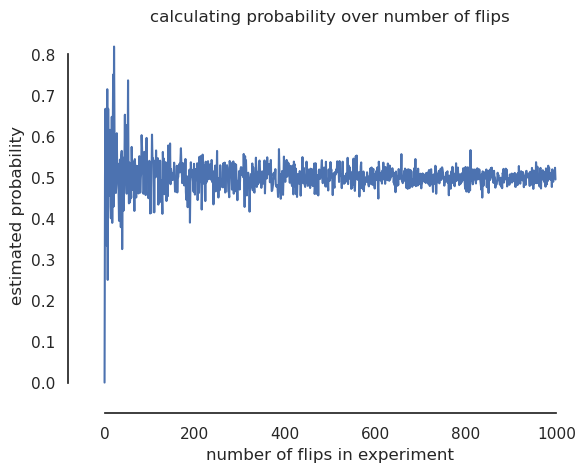

In [21]:
plt.plot(probs)
plt.ylabel('estimated probability')
plt.xlabel('number of flips in experiment')
plt.title('calculating probability over number of flips')
sns.despine(offset=10, trim=True)            # move axes away
plt.show()

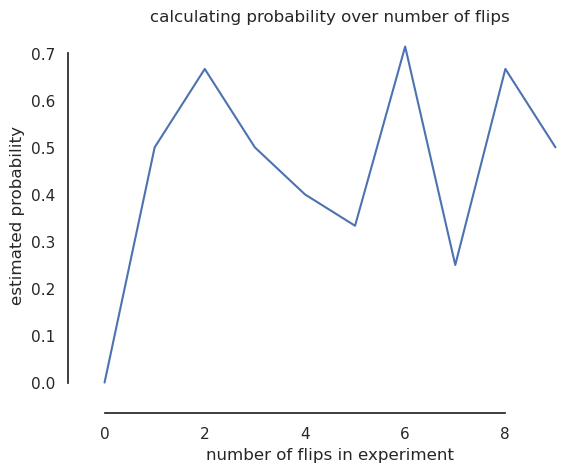

In [22]:
# plotting the starting values of probs to see how coin flips was happing at the start

plt.plot(probs[:10])
plt.ylabel('estimated probability')
plt.xlabel('number of flips in experiment')
plt.title('calculating probability over number of flips')
sns.despine(offset=10, trim=True)            # move axes away
plt.show()

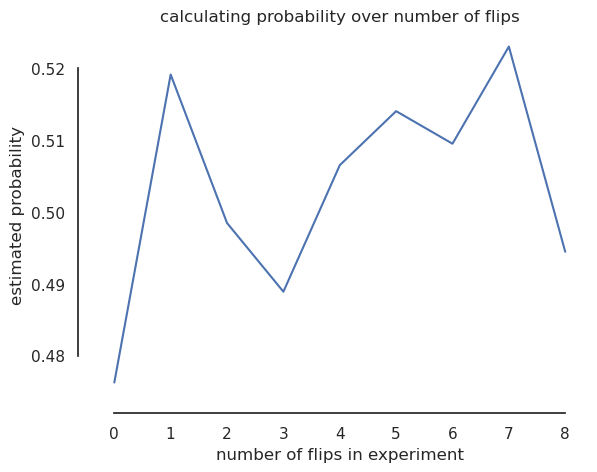

In [23]:
# plotting the last ten values of probs to see how coin flips happens

plt.plot(probs[maximum_flips-10:])
plt.ylabel('estimated probability')
plt.xlabel('number of flips in experiment')
plt.title('calculating probability over number of flips')
sns.despine(offset=10, trim=True)            # move axes away
plt.show()

# see even after ten thousand values it is jumping around 0.5, you can also see in the above 10000 values graph it is still oscilating at the 
# end of the graph, it is not converging. 

In [24]:
# see the above two plots, these are not interactive and showing the wrong numbers of flips for the last number of values, for that we will 
# use a new library which is also built on matplotlib named bokeh

# Bokeh for interactive plots

In [25]:
!pip install bokeh

In [26]:
from bokeh.io import show, output_notebook
from bokeh.plotting import figure

output_notebook()

Loading BokehJS ...

In [29]:
p = figure(title="Simple line plot in Bokeh", 
          x_axis_label="number of flips in experiment",
          y_axis_label='estimated_probability',
          width=680, height=380)

In [30]:
# Delete the old x variable if it exists
if 'x' in globals():
    del x

# add a line renderer with legend and line thickness
x = list(range(1, maximum_flips))
p.line(x=x, y=probs, legend_label='estimated probability', line_width=2)

# show the results 
show(p)